In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


drive_dir = "/content/drive/MyDrive"


Mounted at /content/drive
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 1. ECA LAYER — must match training exactly
# ─────────────────────────────────────────────
class ECALayer(nn.Module):
    def __init__(self, channel, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k_size,
                                  padding=(k_size - 1) // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)                          # (B, C, 1, 1)
        y = self.conv(y.squeeze(-1).transpose(-1,-2)) # (B, 1, C)
        y = self.sigmoid(y).transpose(-1,-2).unsqueeze(-1)  # (B, C, 1, 1)
        return x * y.expand_as(x)


In [ ]:
# ─────────────────────────────────────────────
# 2. MODEL BUILDERS — must match training code
# ─────────────────────────────────────────────
def build_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=None)
    model.features.add_module("eca", ECALayer(model.last_channel))
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(device)


def build_resnet50(num_classes):
    model = models.resnet50(weights=None)

    class Layer4WithECA(nn.Module):
        def __init__(self, layer4, eca):
            super().__init__()
            self.layer4 = layer4
            self.eca    = eca
        def forward(self, x):
            return self.eca(self.layer4(x))

    model.layer4 = Layer4WithECA(model.layer4, ECALayer(2048))
    model.fc     = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(device)

In [ ]:
# ─────────────────────────────────────────────
# 3. LOAD MODELS
# ─────────────────────────────────────────────
def load_model(builder_fn, checkpoint_path, num_classes):
    model = builder_fn(num_classes)
    state = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Handle both plain state_dict and checkpoint dict formats
    if "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
        print(f"Loaded {checkpoint_path} | "
              f"val_acc={state.get('val_accuracy', 'N/A')} | "
              f"test_acc={state.get('test_accuracy', 'N/A')}")
        return model, state
    else:
        model.load_state_dict(state)
        print(f"Loaded {checkpoint_path}")
        return model, {}

resnet_ckpt_path    = f"/content/drive/MyDrive/fine_tuned_resnet50_eca_checkpoint.pth"
mobilenet_ckpt_path = f"/content/drive/MyDrive/fine_tuned_mobilenetv2_eca_checkpoint.pth"

# Get num_classes from checkpoint
tmp = torch.load(resnet_ckpt_path, map_location=device, weights_only=False)
num_classes = tmp["num_classes"]
idx_to_class = tmp["idx_to_class"]
class_names  = [idx_to_class.get(i, idx_to_class.get(str(i), f"class_{i}"))
                for i in range(num_classes)]
print(f"Classes ({num_classes}): {class_names}")

resnet,    resnet_ckpt    = load_model(build_resnet50,
                                       resnet_ckpt_path,
                                       num_classes)
mobilenet, mobilenet_ckpt = load_model(build_mobilenetv2,
                                       mobilenet_ckpt_path,
                                       num_classes)
resnet.eval()
mobilenet.eval()
print("Both models loaded successfully!")

Classes (8): ['Algal leaf spot', 'Brown blight', 'Gray blight', 'Green mirid bug', 'Healthy', 'Helopeltis', 'Red leaf spot', 'Red spider']
Loaded /content/drive/MyDrive/fine_tuned_resnet50_eca_checkpoint.pth | val_acc=95.75671852899576 | test_acc=95.4834156669019
Loaded /content/drive/MyDrive/fine_tuned_mobilenetv2_eca_checkpoint.pth | val_acc=91.15983026874116 | test_acc=90.82568807339449
Both models loaded successfully!


In [ ]:
# ─────────────────────────────────────────────
# 4. DATASET & LOADERS
# ─────────────────────────────────────────────
input_size = 224

base_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# TTA — horizontal flip version
tta_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dir = "/content/drive/MyDrive/Dataset/test"

test_dataset     = datasets.ImageFolder(test_dir, transform=base_transform)
test_dataset_tta = datasets.ImageFolder(test_dir, transform=tta_transform)

test_loader     = DataLoader(test_dataset,     batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tta = DataLoader(test_dataset_tta, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


print(f"Classes ({num_classes}):", class_names)

Classes (8): ['Algal leaf spot', 'Brown blight', 'Gray blight', 'Green mirid bug', 'Healthy', 'Helopeltis', 'Red leaf spot', 'Red spider']


In [ ]:
# Verify class order matches checkpoint — catches silent bugs
assert list(test_dataset.classes) == list(class_names), (
    f"Class order mismatch!\n"
    f"  Folder : {list(test_dataset.classes)}\n"
    f"  Checkpoint: {list(class_names)}"
)
print(f"Class order verified — matches checkpoint ✓")

Class order verified — matches checkpoint ✓


In [ ]:
# ─────────────────────────────────────────────
# 5. GET PROBABILITIES (base + TTA)
# ─────────────────────────────────────────────
def get_probs(model, loader):
    all_probs  = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            out    = model(images)
            probs  = F.softmax(out, dim=1).cpu()
            all_probs.append(probs)
            all_labels.extend(labels.numpy())
    return torch.cat(all_probs, dim=0), np.array(all_labels)

print("\nExtracting probabilities...")
resnet_probs_base,    labels       = get_probs(resnet,    test_loader)
resnet_probs_tta,     _            = get_probs(resnet,    test_loader_tta)
mobilenet_probs_base, _            = get_probs(mobilenet, test_loader)
mobilenet_probs_tta,  _            = get_probs(mobilenet, test_loader_tta)

# Average base + TTA for each model
resnet_probs    = (resnet_probs_base    + resnet_probs_tta)    / 2.0
mobilenet_probs = (mobilenet_probs_base + mobilenet_probs_tta) / 2.0

np.save(f"/content/drive/MyDrive/test_resnet_probs.npy",    resnet_probs.numpy())
np.save(f"/content/drive/MyDrive/test_mobilenet_probs.npy", mobilenet_probs.numpy())
np.save(f"/content/drive/MyDrive/test_labels.npy",          labels)
print("Test probabilities saved to Drive.")
print("Probabilities extracted with TTA.")


Extracting probabilities...
Test probabilities saved to Drive.
Probabilities extracted with TTA.


In [ ]:
# ─────────────────────────────────────────────
# SECTION 6 — Individual Model Accuracies
# ─────────────────────────────────────────────
resnet_preds   = resnet_probs.argmax(1).numpy()
mobilenet_preds = mobilenet_probs.argmax(1).numpy()

print(f"\nResNet50   Test Accuracy (TTA): "
      f"{accuracy_score(labels, resnet_preds):.4f}")
print(f"MobileNetV2 Test Accuracy (TTA): "
      f"{accuracy_score(labels, mobilenet_preds):.4f}")


ResNet50   Test Accuracy (TTA): 0.9548
MobileNetV2 Test Accuracy (TTA): 0.9083


In [ ]:
# ─────────────────────────────────────────────
# SECTION 7 — Ensemble Strategies
# ─────────────────────────────────────────────
# Use OOF accuracy from checkpoints as weights
# OOF accuracy is more reliable than val accuracy
# because it represents performance across all train folds
resnet_oof_acc    = resnet_ckpt.get("oof_accuracy", 95.97)
mobilenet_oof_acc = mobilenet_ckpt.get("oof_accuracy", 94.84)

print(f"\nOOF accuracies used for weighting:")
print(f"  ResNet50    : {resnet_oof_acc:.2f}%")
print(f"  MobileNetV2 : {mobilenet_oof_acc:.2f}%")

total = resnet_oof_acc + mobilenet_oof_acc
w1    = resnet_oof_acc    / total
w2    = mobilenet_oof_acc / total

# Squared weights — emphasizes stronger model more
w1_sq = resnet_oof_acc**2    / (resnet_oof_acc**2 + mobilenet_oof_acc**2)
w2_sq = mobilenet_oof_acc**2 / (resnet_oof_acc**2 + mobilenet_oof_acc**2)

strategies = {
    "ResNet50 only":        resnet_probs.argmax(1).numpy(),
    "MobileNetV2 only":     mobilenet_probs.argmax(1).numpy(),
    "Simple average":      ((resnet_probs + mobilenet_probs) / 2).argmax(1).numpy(),
    "Weighted (linear)":   (w1 * resnet_probs + w2 * mobilenet_probs).argmax(1).numpy(),
    "Weighted (squared)":  (w1_sq * resnet_probs + w2_sq * mobilenet_probs).argmax(1).numpy(),
}

print(f"\n{'─'*45}")
print(f"{'Strategy':<28} {'Accuracy':>10}")
print(f"{'─'*45}")

best_acc, best_name, best_preds = 0, "", None
best_probs = None

for name, preds in strategies.items():
    acc = accuracy_score(labels, preds)
    print(f"{name:<28} {acc:>10.4f}")
    if acc >= best_acc:
        best_acc   = acc
        best_name  = name
        best_preds = preds

print(f"{'─'*45}")
print(f"Best: {best_name} ({best_acc:.4f})")



OOF accuracies used for weighting:
  ResNet50    : 95.36%
  MobileNetV2 : 89.22%

─────────────────────────────────────────────
Strategy                       Accuracy
─────────────────────────────────────────────
ResNet50 only                    0.9548
MobileNetV2 only                 0.9083
Simple average                   0.9591
Weighted (linear)                0.9591
Weighted (squared)               0.9584
─────────────────────────────────────────────
Best: Weighted (linear) (0.9591)


In [ ]:
# ─────────────────────────────────────────────
# 8. FULL EVALUATION ON BEST STRATEGY
# ─────────────────────────────────────────────
# Find all strategies that achieved the best accuracy
strategy_predictions = {
    "Simple average":
        ((resnet_probs + mobilenet_probs) / 2).argmax(1).numpy(),

    "Weighted (linear)":
        (w1 * resnet_probs + w2 * mobilenet_probs).argmax(1).numpy(),

    "Weighted (squared)":
        (w1_sq * resnet_probs + w2_sq * mobilenet_probs).argmax(1).numpy()
}

strategy_acc = {
    name: accuracy_score(labels, preds)
    for name, preds in strategy_predictions.items()
}

best_acc = max(strategy_acc.values())

best_strategies = [
    name for name, acc in strategy_acc.items()
    if acc == best_acc
]

print("\nBest ensemble strategy(ies):")
for s in best_strategies:
    print(f"  {s} ({strategy_acc[s]:.4f})")

# Evaluate each best strategy
for strategy in best_strategies:

    preds = strategy_predictions[strategy]

    print("\n" + "="*60)
    print(strategy)
    print("="*60)

    precision = precision_score(
        labels, preds, average='weighted'
    )

    recall = recall_score(
        labels, preds, average='weighted'
    )

    f1 = f1_score(
        labels, preds, average='weighted'
    )

    print(f"Accuracy : {strategy_acc[strategy]:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    report = classification_report(
        labels,
        preds,
        target_names=class_names
    )

    print(report)

    filename = strategy.lower().replace(" ", "_").replace("(", "").replace(")", "")

    with open(
        f"/content/drive/MyDrive/{filename}_classification_report.txt",
        "w"
    ) as f:
        f.write(report)


Best ensemble strategy(ies):
  Simple average (0.9591)
  Weighted (linear) (0.9591)

Simple average
Accuracy : 0.9591
Precision: 0.9601
Recall   : 0.9591
F1 Score : 0.9592
                 precision    recall  f1-score   support

Algal leaf spot       0.97      0.96      0.97       196
   Brown blight       0.93      0.92      0.92       177
    Gray blight       0.97      0.92      0.94       242
Green mirid bug       0.87      0.96      0.91       126
        Healthy       0.97      1.00      0.99       266
     Helopeltis       0.98      0.96      0.97       197
  Red leaf spot       1.00      0.97      0.99       150
     Red spider       0.94      0.98      0.96        63

       accuracy                           0.96      1417
      macro avg       0.95      0.96      0.96      1417
   weighted avg       0.96      0.96      0.96      1417


Weighted (linear)
Accuracy : 0.9591
Precision: 0.9601
Recall   : 0.9591
F1 Score : 0.9592
                 precision    recall  f1-score   

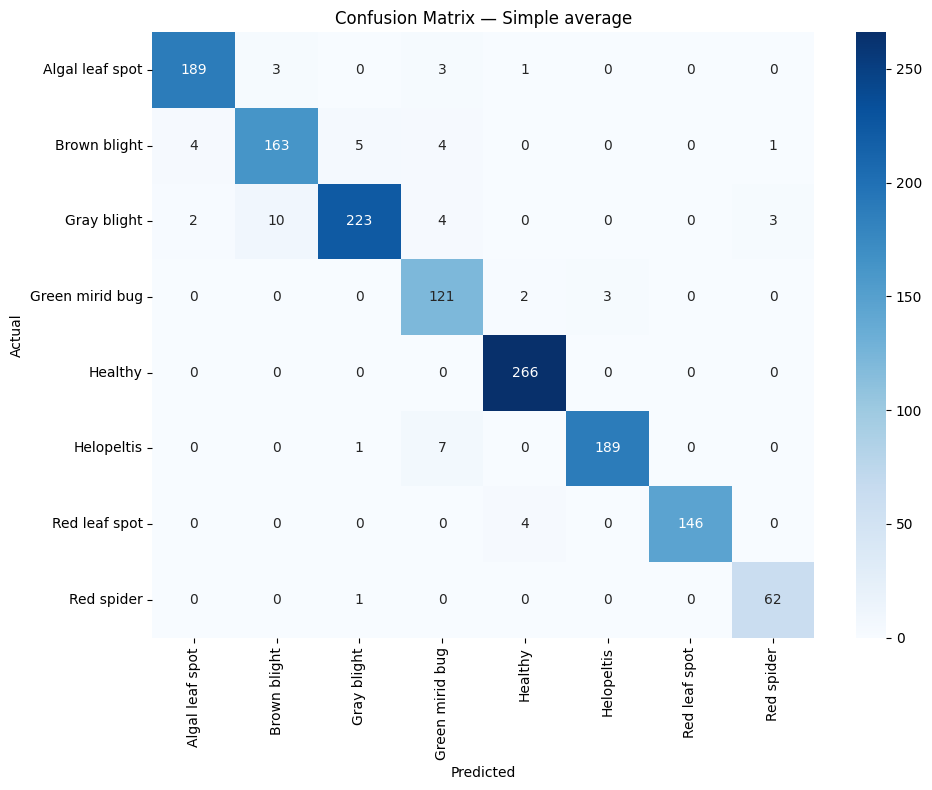

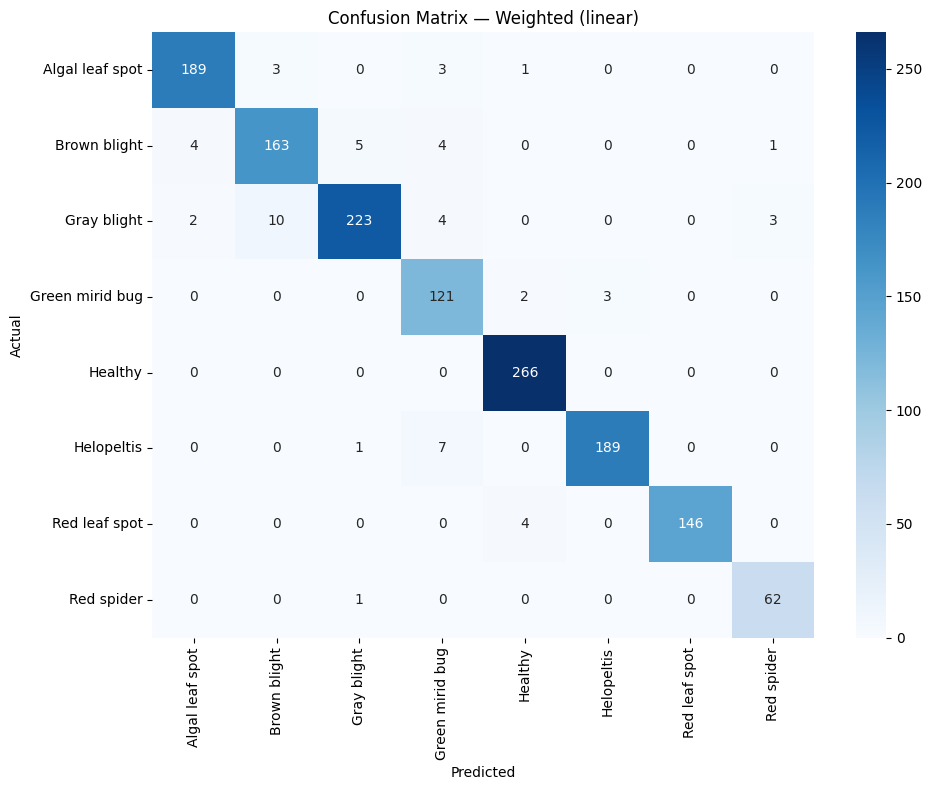

In [ ]:
# ─────────────────────────────────────────────
# 9. CONFUSION MATRIX
# ─────────────────────────────────────────────
for strategy in best_strategies:

    preds = strategy_predictions[strategy]

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {strategy}")

    plt.tight_layout()

    filename = strategy.lower().replace(" ", "_").replace("(", "").replace(")", "")

    plt.savefig(
        f"/content/drive/MyDrive/{filename}_confusion_matrix.png",
        dpi=300
    )

    plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 10. PER-CLASS ACCURACY — which model wins per class
# ─────────────────────────────────────────────
print("\nPer-class accuracy comparison:")
print(f"{'Class':<20} {'ResNet50':>10} {'MobileNetV2':>12} {'Ensemble':>10} {'Winner':>10}")
print("-"*65)

for i, cls in enumerate(class_names):
    mask          = labels == i
    acc_r  = (resnet_preds[mask] == labels[mask]).mean()
    acc_m  = (mobilenet_preds[mask] == labels[mask]).mean()
    acc_e  = (best_preds[mask]         == labels[mask]).mean()
    winner = "ResNet" if acc_r >= acc_m else "MobileNet"
    print(f"{cls:<20} {acc_r:>10.3f} {acc_m:>12.3f} {acc_e:>10.3f} {winner:>10}")


Per-class accuracy comparison:
Class                  ResNet50  MobileNetV2   Ensemble     Winner
-----------------------------------------------------------------
Algal leaf spot           0.954        0.944      0.964     ResNet
Brown blight              0.910        0.910      0.921     ResNet
Gray blight               0.934        0.777      0.921     ResNet
Green mirid bug           0.937        0.913      0.960     ResNet
Healthy                   1.000        0.977      1.000     ResNet
Helopeltis                0.954        0.883      0.959     ResNet
Red leaf spot             0.987        0.953      0.973     ResNet
Red spider                0.937        0.968      0.984  MobileNet
